Libraries imported successfully!

Dataset loaded successfully!
Dataset shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

Missing values:
label      0
message    0
dtype: int64

Duplicate rows:
403

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Dataset after cleaning:
Rows: 5169
Columns: 2

Original and cleaned messages:


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...
5,FreeMsg Hey there darling it's been 3 week's n...,freemsg hey there darling its been weeks now a...
6,Even my brother is not like to speak with me. ...,even my brother is not like to speak with me t...
7,As per your request 'Melle Melle (Oru Minnamin...,as per your request melle melle oru minnaminun...
8,WINNER!! As a valued network customer you have...,winner as a valued network customer you have b...
9,Had your mobile 11 months or more? U R entitle...,had your mobile months or more u r entitled to...



Average message length by class:


,message_length
label,
0,66.18
1,111.21


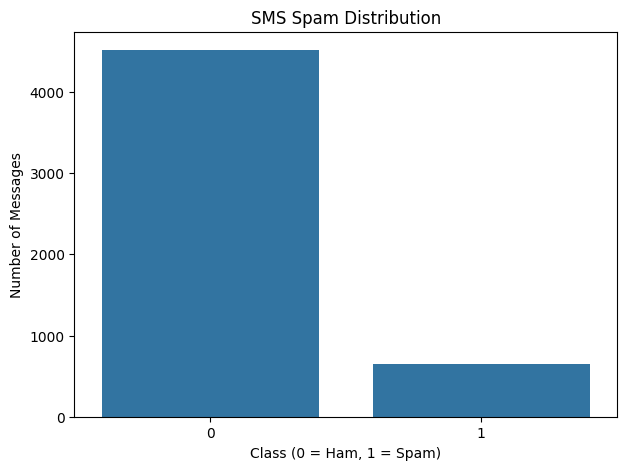

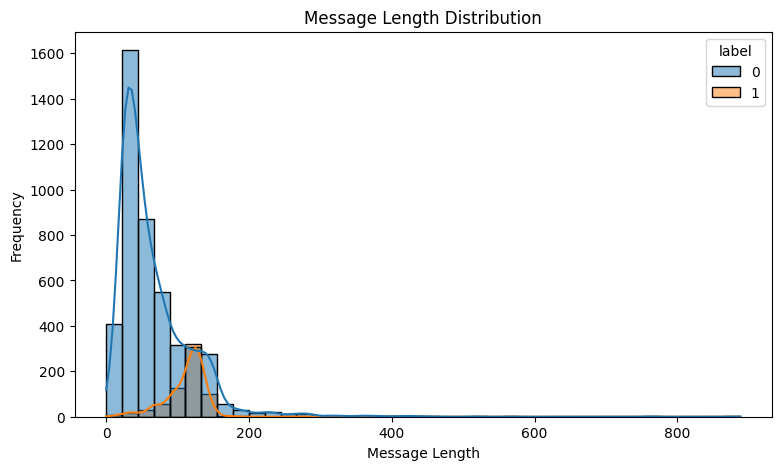


Training messages: 4135
Testing messages: 1034

TF-IDF vectorization completed!
Training matrix shape: (4135, 5000)
Testing matrix shape: (1034, 5000)

Logistic Regression model trained successfully!

MODEL PERFORMANCE
Accuracy: 94.97 %
ROC-AUC: 0.9891

Classification Report:
              precision    recall  f1-score   support

         Ham       0.95      1.00      0.97       903
        Spam       0.98      0.62      0.76       131

    accuracy                           0.95      1034
   macro avg       0.96      0.81      0.86      1034
weighted avg       0.95      0.95      0.94      1034



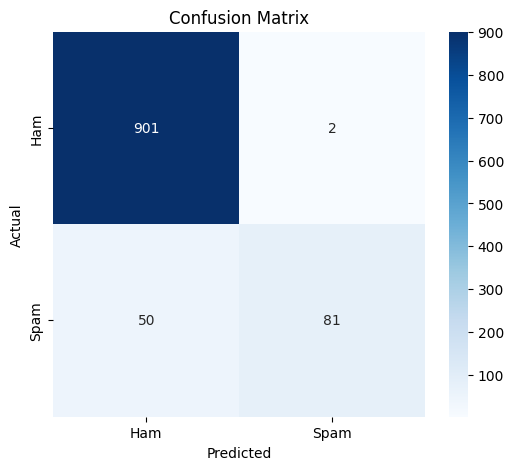


Most influential words:


,Word,Coefficient,Absolute_Coefficient
4513,txt,4.445996,4.445996
2661,mobile,3.607816,3.607816
4230,text,3.475154,3.475154
1270,free,3.472988,3.472988
606,claim,3.472905,3.472905
4031,stop,3.169206,3.169206
3508,reply,3.139607,3.139607
3312,prize,2.855437,2.855437
4906,won,2.596883,2.596883
2853,new,2.498757,2.498757



Top words associated with Spam:


,Word,Coefficient
4513,txt,4.445996
2661,mobile,3.607816
4230,text,3.475154
1270,free,3.472988
606,claim,3.472905
4031,stop,3.169206
3508,reply,3.139607
3312,prize,2.855437
4906,won,2.596883
2853,new,2.498757



Top words associated with Ham:


,Word,Coefficient
1865,im,-1.902467
2436,ltgt,-1.869628
2974,ok,-1.790741
1832,ill,-1.717328
676,come,-1.375059
1730,home,-1.305212
2366,lor,-1.282747
1426,going,-1.192670
1477,got,-1.139829
858,da,-1.137479


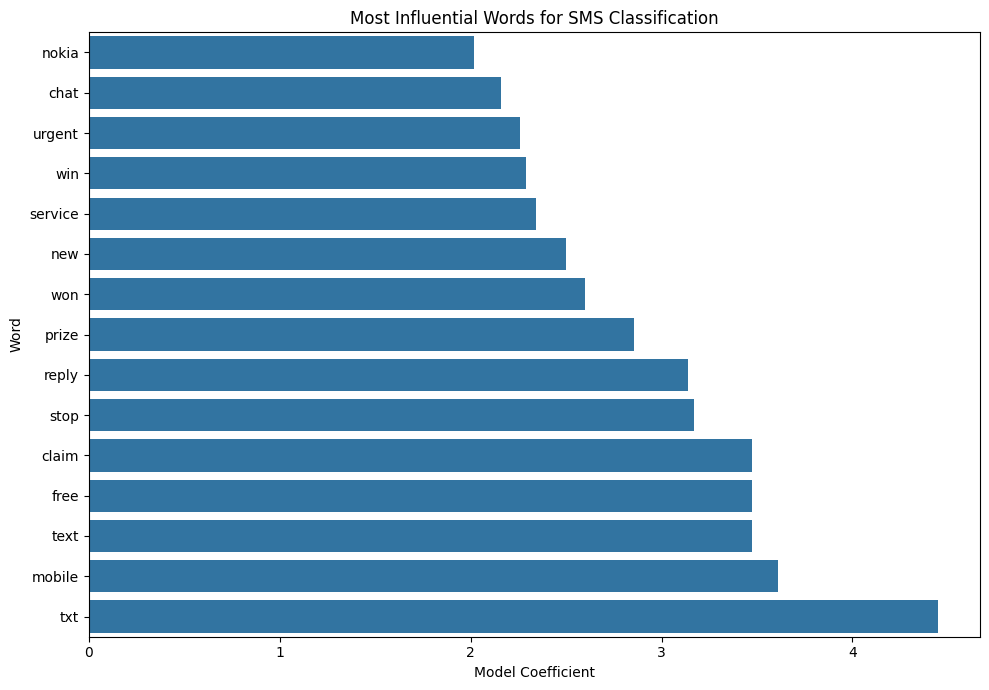


Sample predictions:


,Message,Actual,Predicted,Spam_Probability,Actual_Label,Predicted_Label
0,good morning my love i go to sleep now and wis...,0,0,0.0241,Ham,Ham
1,and how you will do that princess,0,0,0.0481,Ham,Ham
2,cool ill text you when im on the way,0,0,0.0546,Ham,Ham
3,your right ill make the appointment right now,0,0,0.0396,Ham,Ham
4,aiya we discuss later lar pick up at is it,0,0,0.0386,Ham,Ham
5,maybe say hi to and find out if got his card g...,0,0,0.0369,Ham,Ham
6,lemme know when i can swing by and pick up im ...,0,0,0.0626,Ham,Ham
7,yes please leave at ltgt so that at ltgt we ca...,0,0,0.0253,Ham,Ham
8,i am in bus on the way to calicut,0,0,0.0418,Ham,Ham
9,o we cant see if we can join denis and mina or...,0,0,0.0723,Ham,Ham



----------------------------------------
SMS: Congratulations! You have won a free prize. Click now!
Prediction: SPAM
Spam Probability: 83.6 %
----------------------------------------

----------------------------------------
SMS: Hey, are we still meeting tomorrow?
Prediction: HAM
Spam Probability: 2.98 %
----------------------------------------

----------------------------------------
SMS: You have been selected for a special cash reward.
Prediction: HAM
Spam Probability: 40.41 %
----------------------------------------

Prediction files saved successfully!

SMS SPAM CLASSIFICATION WITH NLP COMPLETED

✓ Dataset loaded
✓ Data explored
✓ Duplicate messages removed
✓ Missing values handled
✓ Text cleaned
✓ Text converted to lowercase
✓ URLs removed
✓ Special characters removed
✓ Message length analyzed
✓ Train/Test split completed
✓ TF-IDF vectorization completed
✓ Logistic Regression model trained
✓ SMS messages classified
✓ Accuracy calculated
✓ ROC-AUC calculated
✓ Classification r

In [1]:
# ============================================================
# SMS SPAM CLASSIFICATION WITH NLP
# Natural Language Processing + Machine Learning
# Google Colab Project
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("Libraries imported successfully!")


# ============================================================
# 2. LOAD DATASET
# ============================================================

url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"

df = pd.read_csv(
    url,
    sep="\t",
    header=None,
    names=["label", "message"]
)

print("\nDataset loaded successfully!")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())


# ============================================================
# 3. DATA EXPLORATION
# ============================================================

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nClass distribution:")
print(df["label"].value_counts())


# ============================================================
# 4. DATA CLEANING
# ============================================================

# Remove duplicate messages
df = df.drop_duplicates()

# Remove missing values
df = df.dropna()

# Convert labels:
# ham  = 0
# spam = 1

df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("\nDataset after cleaning:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


# ============================================================
# 5. TEXT PREPROCESSING
# ============================================================

def clean_text(text):

    text = str(text)

    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+|https\S+",
        "",
        text
    )

    # Remove special characters and numbers
    text = re.sub(
        r"[^a-zA-Z\s]",
        "",
        text
    )

    # Remove extra spaces
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


df["clean_message"] = df["message"].apply(clean_text)

print("\nOriginal and cleaned messages:")

display(
    df[["message", "clean_message"]].head(10)
)


# ============================================================
# 6. MESSAGE LENGTH
# ============================================================

df["message_length"] = df["clean_message"].str.len()

print("\nAverage message length by class:")

display(
    df.groupby("label")["message_length"]
      .mean()
      .round(2)
)


# ============================================================
# 7. CLASS DISTRIBUTION VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="label"
)

plt.title("SMS Spam Distribution")
plt.xlabel("Class (0 = Ham, 1 = Spam)")
plt.ylabel("Number of Messages")

plt.show()


# ============================================================
# 8. MESSAGE LENGTH VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="message_length",
    hue="label",
    bins=40,
    kde=True
)

plt.title("Message Length Distribution")
plt.xlabel("Message Length")
plt.ylabel("Frequency")

plt.show()


# ============================================================
# 9. PREPARE FEATURES AND TARGET
# ============================================================

X = df["clean_message"]
y = df["label"]


# ============================================================
# 10. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining messages:", len(X_train))
print("Testing messages:", len(X_test))


# ============================================================
# 11. TF-IDF VECTORIZATION
# ============================================================

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english",
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(
    X_train
)

X_test_tfidf = vectorizer.transform(
    X_test
)

print("\nTF-IDF vectorization completed!")

print(
    "Training matrix shape:",
    X_train_tfidf.shape
)

print(
    "Testing matrix shape:",
    X_test_tfidf.shape
)


# ============================================================
# 12. TRAIN LOGISTIC REGRESSION MODEL
# ============================================================

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_tfidf,
    y_train
)

print("\nLogistic Regression model trained successfully!")


# ============================================================
# 13. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test_tfidf
)

y_probability = model.predict_proba(
    X_test_tfidf
)[:, 1]


# ============================================================
# 14. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("\n============================================================")
print("MODEL PERFORMANCE")
print("============================================================")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

print(
    "ROC-AUC:",
    round(roc_auc, 4)
)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    )
)


# ============================================================
# 15. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# ============================================================
# 16. IMPORTANT WORDS FOR SPAM CLASSIFICATION
# ============================================================

feature_names = vectorizer.get_feature_names_out()

coefficients = model.coef_[0]

word_importance = pd.DataFrame({
    "Word": feature_names,
    "Coefficient": coefficients
})

word_importance["Absolute_Coefficient"] = (
    word_importance["Coefficient"].abs()
)

word_importance = word_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

print("\nMost influential words:")

display(
    word_importance.head(20)
)


# ============================================================
# 17. TOP SPAM WORDS
# ============================================================

spam_words = word_importance.sort_values(
    "Coefficient",
    ascending=False
).head(15)

print("\nTop words associated with Spam:")

display(
    spam_words[["Word", "Coefficient"]]
)


# ============================================================
# 18. TOP HAM WORDS
# ============================================================

ham_words = word_importance.sort_values(
    "Coefficient",
    ascending=True
).head(15)

print("\nTop words associated with Ham:")

display(
    ham_words[["Word", "Coefficient"]]
)


# ============================================================
# 19. VISUALIZE IMPORTANT WORDS
# ============================================================

top_words = word_importance.head(15).sort_values(
    "Coefficient"
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_words,
    x="Coefficient",
    y="Word"
)

plt.title(
    "Most Influential Words for SMS Classification"
)

plt.xlabel("Model Coefficient")
plt.ylabel("Word")

plt.tight_layout()

plt.show()


# ============================================================
# 20. CREATE PREDICTION DATAFRAME
# ============================================================

prediction_df = pd.DataFrame({
    "Message": X_test.values,
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Spam_Probability": y_probability.round(4)
})

prediction_df["Actual_Label"] = (
    prediction_df["Actual"]
    .map({
        0: "Ham",
        1: "Spam"
    })
)

prediction_df["Predicted_Label"] = (
    prediction_df["Predicted"]
    .map({
        0: "Ham",
        1: "Spam"
    })
)

print("\nSample predictions:")

display(
    prediction_df.head(10)
)


# ============================================================
# 21. CUSTOM SMS PREDICTION FUNCTION
# ============================================================

def predict_sms(message):

    cleaned_message = clean_text(message)

    transformed_message = vectorizer.transform(
        [cleaned_message]
    )

    prediction = model.predict(
        transformed_message
    )[0]

    probability = model.predict_proba(
        transformed_message
    )[0][1]

    if prediction == 1:
        label = "SPAM"
    else:
        label = "HAM"

    print("\n----------------------------------------")
    print("SMS:", message)
    print("Prediction:", label)
    print(
        "Spam Probability:",
        round(probability * 100, 2),
        "%"
    )
    print("----------------------------------------")


# ============================================================
# 22. TEST CUSTOM SMS MESSAGES
# ============================================================

predict_sms(
    "Congratulations! You have won a free prize. Click now!"
)

predict_sms(
    "Hey, are we still meeting tomorrow?"
)

predict_sms(
    "You have been selected for a special cash reward."
)


# ============================================================
# 23. SAVE PREDICTIONS
# ============================================================

prediction_df.to_csv(
    "sms_spam_predictions.csv",
    index=False
)

word_importance.to_csv(
    "important_words.csv",
    index=False
)

print("\nPrediction files saved successfully!")


# ============================================================
# 24. FINAL PROJECT SUMMARY
# ============================================================

print("""
============================================================
SMS SPAM CLASSIFICATION WITH NLP COMPLETED
============================================================

✓ Dataset loaded
✓ Data explored
✓ Duplicate messages removed
✓ Missing values handled
✓ Text cleaned
✓ Text converted to lowercase
✓ URLs removed
✓ Special characters removed
✓ Message length analyzed
✓ Train/Test split completed
✓ TF-IDF vectorization completed
✓ Logistic Regression model trained
✓ SMS messages classified
✓ Accuracy calculated
✓ ROC-AUC calculated
✓ Classification report generated
✓ Confusion matrix created
✓ Important words analyzed
✓ Spam-related words identified
✓ Ham-related words identified
✓ Custom SMS predictions tested
✓ Results exported

============================================================
PROJECT INFORMATION
============================================================

Project Name : SMS Spam Classification with NLP
Project Type : Natural Language Processing
Task         : Text Classification
Model        : Logistic Regression
Technique    : TF-IDF
Environment  : Google Colab

Target:
0 = Ham
1 = Spam

============================================================
""")